# Libraries

In [1]:
import tensorflow as tf
import keras
from keras.models import Sequential, save_model
from keras.layers import Conv1D, Conv1DTranspose, Dense, BatchNormalization, Activation, Input
from keras.constraints import max_norm
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import math
import sys
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix
import sklearn
from sklearn.model_selection import train_test_split

In [2]:
sys.path.append('../src')
from povm_sampling import sample_povm, povm_probability, samples_to_onehot, samples_to_empirical_dist
from statesprep import create_ghz_state, create_w_state
from vae import VAE, KLWarmup, FidelityMonitor

# Data Creation and Processing

In [3]:
# Set samples and qubits to use for the training
N_SAMPLES = [1000, 5000, 10000, 20000, 50000, 100000]
N_QUBITS = [3, 4, 5, 6, 7, 8]

# Create a GHZ state and compute the corresponding density matrix
n_samples = N_SAMPLES[0]
n_qubits = N_QUBITS[0]
qc = create_ghz_state(n_qubits)
rho = DensityMatrix(qc)

# Compute the probability distribution over the outcomes of the POVM measurement and sample from it
prob = povm_probability(rho.data, n_qubits)
sample = sample_povm(prob, n_samples=n_samples)
P_empirical = samples_to_empirical_dist(sample, n_qubits)

# Convert the samples to one-hot encoding
onehot_sample = samples_to_onehot(sample, n_qubits)

In [4]:
# Split the data into training and testing sets (unsupervised: no labels, no stratify)
X_train, X_test = train_test_split(onehot_sample, test_size=0.2, random_state=42)

print(f"Training set size and shape: {len(X_train)} and {X_train.shape}")
print(f"Testing set size and shape: {len(X_test)} and {X_test.shape}")

Training set size and shape: 800 and (800, 12)
Testing set size and shape: 200 and (200, 12)


# Train

In [12]:
# Difine useful parameters for the VAE training
LATENT_DIM = 16
HIDDEN_DIM = 128
WARMUP_EPOCHS = 30
TOTAL_EPOCHS = 2000
BATCH_SIZE = 100

In [13]:
# Instantiate and compile the VAE model
vae = VAE(n_qubits=n_qubits, latent_dim=LATENT_DIM, hidden=HIDDEN_DIM)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))
vae.build(input_shape=(None, 4*n_qubits))
model = vae

In [ ]:
# Compute the exact probability distribution over the POVM outcomes
P_exact = povm_probability(rho.data, n_qubits)

# Define callbacks for training
callbacks = [
    KLWarmup(beta_max=0.85, warmup_epochs=WARMUP_EPOCHS),
    FidelityMonitor(P_exact, n_qubits, n_gen=20000),
    EarlyStopping(monitor='val_loss', mode='min',
                  patience=40, restore_best_weights=True, 
                  start_from_epoch=WARMUP_EPOCHS),
    ReduceLROnPlateau(monitor='val_loss', mode='min',
                      factor=0.5, patience=20, min_lr=1e-6),
]

# fit data
history = model.fit(
    X_train, X_train,
    epochs=TOTAL_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, X_test),
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/2000
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - kl_loss: 0.4340 - kl_weight: 0.0000e+00 - loss: 4.1493 - reconstruction_loss: 4.1493 - val_kl_loss: 0.4661 - val_loss: 4.1234 - val_reconstruction_loss: 4.1234 - val_fidelity: 0.9494 - learning_rate: 0.0010
Epoch 2/2000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - kl_loss: 0.7503 - kl_weight: 0.0283 - loss: 3.9789 - reconstruction_loss: 3.9577 - val_kl_loss: 0.8047 - val_loss: 3.9367 - val_reconstruction_loss: 3.9139 - val_fidelity: 0.9511 - learning_rate: 0.0010
Epoch 3/2000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - kl_loss: 1.3370 - kl_weight: 0.0567 - loss: 3.8429 - reconstruction_loss: 3.7672 - val_kl_loss: 1.4350 - val_loss: 3.7254 - val_reconstruction_loss: 3.6441 - val_fidelity: 0.9519 - learning_rate: 0.0010
Epoch 4/2000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - kl_loss: 2.5375 - kl_weight: 0.0850 - loss: 3.5745 - reconstruction_loss: 3.3589 - val_kl_loss: 2.7081 - val_loss: 3.4950 - val_reconstruction_loss: 3.2648 - val_fidelity: 0.956

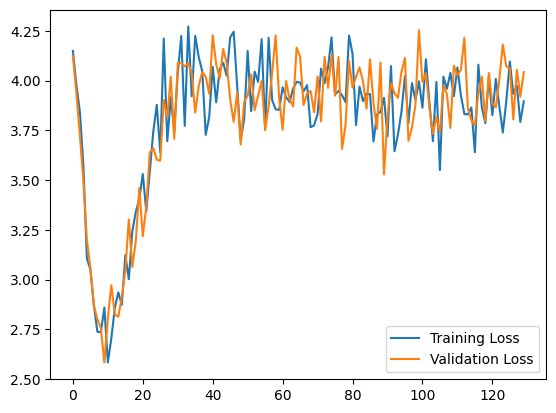

In [7]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()

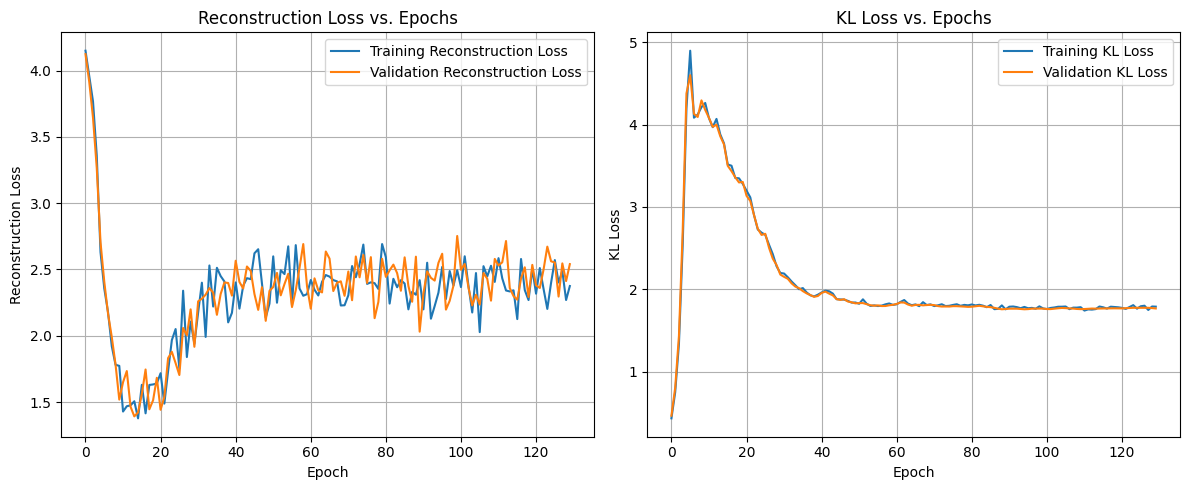

In [8]:
# Plotting reconstruction_loss and kl_loss

plt.figure(figsize=(12, 5))

# Subplot 1: Reconstruction Loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(history.history['reconstruction_loss'], label='Training Reconstruction Loss')
plt.plot(history.history['val_reconstruction_loss'], label='Validation Reconstruction Loss')
plt.title('Reconstruction Loss vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss')
plt.legend()
plt.grid(True)

# Subplot 2: KL Loss
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(history.history['kl_loss'], label='Training KL Loss')
plt.plot(history.history['val_kl_loss'], label='Validation KL Loss')
plt.title('KL Loss vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('KL Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Validation: distribuzione generata vs POVM vera

Le loss non dicono se il VAE riproduce la distribuzione corretta. Qui campioniamo dal modello
(`z ~ N(0,I)` -> decoder -> outcome) e confrontiamo la distribuzione empirica generata con quella
esatta `P(a) = Tr[M(a) rho]` tramite la **fidelity classica** `F_c = sum_x sqrt(P(x)*Q(x))` (Eq. 3 del paper).

Riferimento chiave: `F_c(dati di training, esatta)` e' il **tetto** raggiungibile, limitato solo
dallo shot noise dei dati. Se il VAE ci si avvicina, sta facendo il suo lavoro.

=== FIDELITY CLASSICA (occhio: il floor banale e' ~0.95, non 0!) ===
  rumore uniforme  vs esatta : 0.9510   <- FLOOR (non impara nulla)
  VAE              vs esatta : 0.9754   <- il modello
  dati training    vs esatta : 0.9860   <- TETTO

=== TOTAL VARIATION (0 = identiche, metrica severa e leggibile) ===
  rumore uniforme  vs esatta : 0.2585   <- FLOOR
  VAE              vs esatta : 0.1890   <- il modello (PUNTA a questo)
  dati training    vs esatta : 0.1183   <- TETTO

=== I 4 PICCHI del GHZ: riesce a riprodurli? ===
  outcome      esatta      VAE  uniforme
  (0, 0, 0)    0.0625   0.0404    0.0156
  (1, 1, 1)    0.0339   0.0177    0.0156
  (2, 2, 2)    0.0339   0.0237    0.0156
  (3, 3, 3)    0.0339   0.0210    0.0156


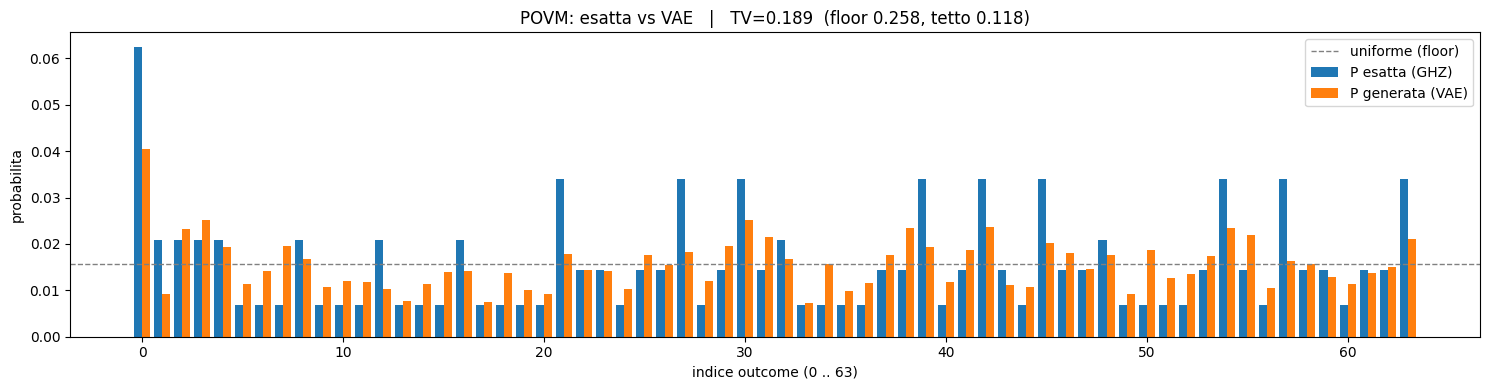

In [ ]:
from povm_sampling import onehot_to_samples

# --- 1. Distribuzione esatta P(a) (ground truth) ---
P_exact = povm_probability(rho.data, n_qubits)
outcomes = list(P_exact.keys())                  # 4^N outcome ordinati

# --- 2. Campiona dal VAE: z ~ N(0,I) -> softmax per gruppo -> outcome categorico ---
def vae_generate(model, n_samples, n_qubits, seed=0):
    rng = np.random.default_rng(seed)
    probs = model.sample(n_samples).numpy().reshape(n_samples, n_qubits, 4)  # (n, N, 4)
    # campiona UNA classe per gruppo secondo le probabilita' del decoder
    # (argmax darebbe solo la moda: perderebbe la distribuzione)
    cum = np.cumsum(probs, axis=-1)
    u = rng.random((n_samples, n_qubits, 1))
    draws = (u < cum).argmax(axis=-1)            # (n, N): outcome per qubit
    return [tuple(int(a) for a in row) for row in draws]

N_GEN = 20000
gen_samples = vae_generate(model, N_GEN, n_qubits)
P_vae = samples_to_empirical_dist(gen_samples, n_qubits)

# --- 3. Metriche ---
def classical_fidelity(P, Q):
    return float(sum(np.sqrt(P.get(x, 0.0) * Q.get(x, 0.0)) for x in set(P) | set(Q)))

def total_variation(P, Q):
    # TV = 1/2 sum|P-Q|: 0=identiche, molto piu' severa di F_c
    return float(0.5 * sum(abs(P.get(x, 0.0) - Q.get(x, 0.0)) for x in set(P) | set(Q)))

# distribuzione empirica dei DATI di training -> tetto raggiungibile (shot noise)
P_train = samples_to_empirical_dist(onehot_to_samples(X_train, n_qubits), n_qubits)

# baseline BANALE: rumore uniforme indipendente (modello che non impara nulla)
P_unif = {o: 1.0 / len(outcomes) for o in outcomes}

print("=== FIDELITY CLASSICA (occhio: il floor banale e' ~0.95, non 0!) ===")
print(f"  rumore uniforme  vs esatta : {classical_fidelity(P_unif,  P_exact):.4f}   <- FLOOR (non impara nulla)")
print(f"  VAE              vs esatta : {classical_fidelity(P_vae,   P_exact):.4f}   <- il modello")
print(f"  dati training    vs esatta : {classical_fidelity(P_train, P_exact):.4f}   <- TETTO")
print()
print("=== TOTAL VARIATION (0 = identiche, metrica severa e leggibile) ===")
print(f"  rumore uniforme  vs esatta : {total_variation(P_unif,  P_exact):.4f}   <- FLOOR")
print(f"  VAE              vs esatta : {total_variation(P_vae,   P_exact):.4f}   <- il modello (PUNTA a questo)")
print(f"  dati training    vs esatta : {total_variation(P_train, P_exact):.4f}   <- TETTO")
print()
print("=== I 4 PICCHI del GHZ: riesce a riprodurli? ===")
print(f"  {'outcome':10s} {'esatta':>8s} {'VAE':>8s} {'uniforme':>9s}")
for o in [(0, 0, 0), (1, 1, 1), (2, 2, 2), (3, 3, 3)]:
    print(f"  {str(o):10s} {P_exact[o]:8.4f} {P_vae.get(o,0):8.4f} {1/len(outcomes):9.4f}")

# --- 4. Confronto visivo sulle 4^N probabilita' ---
p_true = np.array([P_exact[o] for o in outcomes])
p_gen  = np.array([P_vae[o]   for o in outcomes])
idx = np.arange(len(outcomes))

plt.figure(figsize=(15, 4))
plt.bar(idx - 0.2, p_true, width=0.4, label='P esatta (GHZ)')
plt.bar(idx + 0.2, p_gen,  width=0.4, label='P generata (VAE)')
plt.axhline(1/len(outcomes), ls='--', c='gray', lw=1, label='uniforme (floor)')
plt.xlabel(f'indice outcome (0 .. {4**n_qubits - 1})')
plt.ylabel('probabilita')
plt.title(f'POVM: esatta vs VAE   |   TV={total_variation(P_vae, P_exact):.3f}  '
          f'(floor {total_variation(P_unif, P_exact):.3f}, tetto {total_variation(P_train, P_exact):.3f})')
plt.legend()
plt.tight_layout()
plt.show()

# Provo da 3 a 5 qubit

In [13]:
N_SAMPLES = [1000, 5000, 10000, 20000, 50000, 100000]
N_QUBITS = [3, 4, 5]

PLOT_LOSS = False   # True per vedere le curve rec/KL di ogni run (molte figure)

# geometria (latent_dim, hidden, N_GEN) per numero di qubit
CFG = {
    3: dict(latent_dim=16,  hidden=96,  batch_size=100, N_GEN=20000),
    4: dict(latent_dim=32,  hidden=128,  batch_size=200, N_GEN=100000),
    5: dict(latent_dim=64,  hidden=224,  batch_size=500, N_GEN=4**5 * 500),
    6: dict(latent_dim=256, hidden=1280, batch_size=600, N_GEN=4**6 * 500),
    7: dict(latent_dim=512, hidden=1504, batch_size=800, N_GEN=4**7 * 500),
    8: dict(latent_dim=512, hidden=2560, batch_size=1000, N_GEN=4**8 * 500),
}

# accumulo i risultati per il plot finale: una curva per ogni numero di qubit
results = {q: {"n_samples": [], "Fc": [], "Fc_train": []} for q in N_QUBITS}

for q in N_QUBITS:
    for n in N_SAMPLES:
        print(f"\n=== N_QUBITS={q}   N_SAMPLES={n} ===")
        n_samples = n
        n_qubits = q

        # GHZ esatto + distribuzione POVM vera
        qc = create_ghz_state(n_qubits)
        rho = DensityMatrix(qc)
        P_exact = povm_probability(rho.data, n_qubits)
        outcomes = list(P_exact.keys())            # ricalcolato per ogni q (era un bug: restava a 3 qubit)

        # campiona la distribuzione e prepara i dati
        sample = sample_povm(P_exact, n_samples=n_samples)
        onehot_sample = samples_to_onehot(sample, n_qubits)
        X_train, X_test = train_test_split(onehot_sample, test_size=0.2, random_state=42)

        cfg = CFG[q]
        latent_dim, hidden, batch_size, N_GEN = cfg["latent_dim"], cfg["hidden"], cfg["batch_size"], cfg["N_GEN"]

        vae = VAE(n_qubits=n_qubits, latent_dim=latent_dim, hidden=hidden)
        vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))
        vae.build(input_shape=(None, 4 * n_qubits))
        model = vae

        WARMUP = 30   # epoche di warm-up della KL (0 -> beta_max)
        callbacks = [
            KLWarmup(beta_max=0.85, warmup_epochs=WARMUP),
            EarlyStopping(monitor='val_loss', mode='min',
                          patience=40, restore_best_weights=True, start_from_epoch=WARMUP),
        ]

        history = model.fit(
            X_train, X_train,
            epochs=2000,
            batch_size=batch_size,
            validation_data=(X_test, X_test),
            callbacks=callbacks,
            verbose=0,
        )

        if PLOT_LOSS:
            plt.figure(figsize=(12, 5))
            plt.subplot(1, 2, 1)
            plt.plot(history.history['reconstruction_loss'], label='Training Reconstruction Loss')
            plt.plot(history.history['val_reconstruction_loss'], label='Validation Reconstruction Loss')
            plt.title(f'Reconstruction Loss (q={q}, n={n})')
            plt.xlabel('Epoch'); plt.ylabel('Reconstruction Loss'); plt.legend(); plt.grid(True)
            plt.subplot(1, 2, 2)
            plt.plot(history.history['kl_loss'], label='Training KL Loss')
            plt.plot(history.history['val_kl_loss'], label='Validation KL Loss')
            plt.title(f'KL Loss (q={q}, n={n})')
            plt.xlabel('Epoch'); plt.ylabel('KL Loss'); plt.legend(); plt.grid(True)
            plt.tight_layout(); plt.show()

        # campiona dal VAE e calcola le metriche vs la distribuzione esatta
        gen_samples = vae_generate(model, N_GEN, n_qubits)
        P_vae = samples_to_empirical_dist(gen_samples, n_qubits)
        P_train = samples_to_empirical_dist(onehot_to_samples(X_train, n_qubits), n_qubits)
        P_unif = {o: 1.0 / len(outcomes) for o in outcomes}

        Fc       = classical_fidelity(P_vae,   P_exact)
        Fc_train = classical_fidelity(P_train, P_exact)
        print("=== FIDELITY CLASSICA (occhio: il floor banale e' ~0.95, non 0!) ===")
        print(f"  rumore uniforme  vs esatta : {classical_fidelity(P_unif, P_exact):.4f}   <- FLOOR (non impara nulla)")
        print(f"  VAE              vs esatta : {Fc:.4f}   <- il modello")
        print(f"  dati training    vs esatta : {Fc_train:.4f}   <- TETTO")
        print("=== TOTAL VARIATION (0 = identiche, metrica severa e leggibile) ===")
        print(f"  rumore uniforme  vs esatta : {total_variation(P_unif, P_exact):.4f}   <- FLOOR")
        print(f"  VAE              vs esatta : {total_variation(P_vae,  P_exact):.4f}   <- il modello (PUNTA a questo)")
        print(f"  dati training    vs esatta : {total_variation(P_train, P_exact):.4f}   <- TETTO")

        # salvo la fidelity classica per il plot al variare di N_SAMPLES e N_QUBITS
        # (atteso: cresce con n_samples, cala con n_qubits)
        results[q]["n_samples"].append(n)
        results[q]["Fc"].append(Fc)
        results[q]["Fc_train"].append(Fc_train)

print("\nRESULTS:", results)


=== N_QUBITS=3   N_SAMPLES=1000 ===
=== FIDELITY CLASSICA (occhio: il floor banale e' ~0.95, non 0!) ===
  rumore uniforme  vs esatta : 0.9510   <- FLOOR (non impara nulla)
  VAE              vs esatta : 0.9816   <- il modello
  dati training    vs esatta : 0.9860   <- TETTO
=== TOTAL VARIATION (0 = identiche, metrica severa e leggibile) ===
  rumore uniforme  vs esatta : 0.2585   <- FLOOR
  VAE              vs esatta : 0.1605   <- il modello (PUNTA a questo)
  dati training    vs esatta : 0.1183   <- TETTO

=== N_QUBITS=3   N_SAMPLES=5000 ===
=== FIDELITY CLASSICA (occhio: il floor banale e' ~0.95, non 0!) ===
  rumore uniforme  vs esatta : 0.9510   <- FLOOR (non impara nulla)
  VAE              vs esatta : 0.9912   <- il modello
  dati training    vs esatta : 0.9980   <- TETTO
=== TOTAL VARIATION (0 = identiche, metrica severa e leggibile) ===
  rumore uniforme  vs esatta : 0.2585   <- FLOOR
  VAE              vs esatta : 0.1126   <- il modello (PUNTA a questo)
  dati training    vs

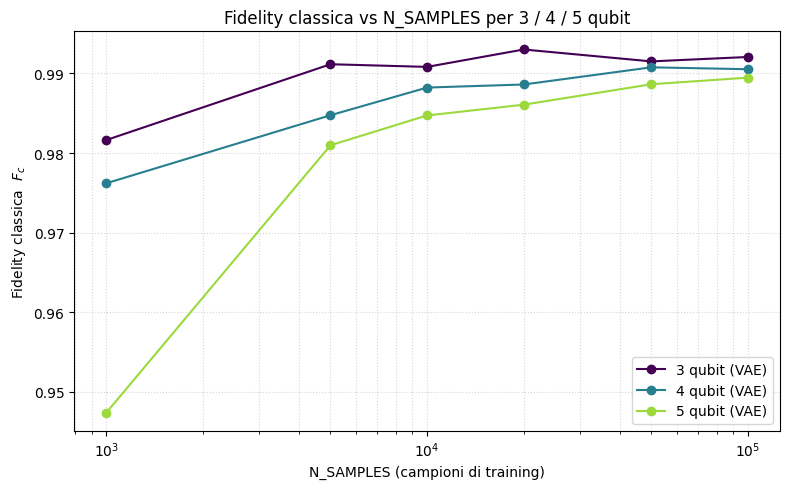

In [15]:
# Fidelity classica al variare di N_SAMPLES, una curva per ogni numero di qubit (sovrapposte)
# NB: nel loop varia N_SAMPLES (campioni di training/misure); N_GEN e' fisso per ogni q.
# Atteso: F_c cresce con N_SAMPLES e cala con N_QUBITS.

plt.figure(figsize=(8, 5))
colors = plt.cm.viridis(np.linspace(0, 0.85, len(results)))

for color, (q, r) in zip(colors, sorted(results.items())):
    ns = r["n_samples"]
    plt.plot(ns, r["Fc"], '-o', color=color, label=f'{q} qubit (VAE)')
    # tetto raggiungibile (fidelity dei dati di training vs esatta): tratteggiato
    #plt.plot(ns, r["Fc_train"], '--', color=color, alpha=0.5,
    #         label=f'{q} qubit (tetto: dati)')

plt.xscale('log')
plt.xlabel('N_SAMPLES (campioni di training)')
plt.ylabel('Fidelity classica  $F_c$')
plt.title('Fidelity classica vs N_SAMPLES per 3 / 4 / 5 qubit')
plt.grid(True, which='both', ls=':', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
